Задание 1:

Выберите 2 любые компании, которые имеют листинг на фондовом рынке США. Выгрузите дневные данные начиная с 2017 по настоящее время по этим 2-м компаниям и сформируйте датасет для временного ряда (итого у вас 2 датасета). 
Цель задания - проведите исследование и статистический анализ временного ряда по сформированным датасетам, посчитайте все основные статистики для временного ряда, превратите ваши временные ряды в стационарные и сформируйте отчет с выводами и визуализациями в jupyter notebook’e.

# Анализ временных рядов ASML и WMT

**Компании:** ASML Holding (NASDAQ: ASML) — полупроводниковое оборудование; Walmart (NYSE: WMT) — розничная торговля.

**Период:** дневные котировки с 2017-01-01 по текущую дату.

**Цель:** описательная статистика, визуализации, автокорреляция со проверкой значимости, тест Дики–Фуллера, приведение рядов к слабой стационарности и выводы.

In [1]:
# pip install yfinance mplfinance statsmodels scipy  # при необходимости
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.tsa.api as smt
from scipy.stats import t as student_t
from statsmodels.tsa.stattools import adfuller
import yfinance as yf
import mplfinance as mpf

%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 4)
plt.rcParams['axes.grid'] = True

TICKERS = ['ASML', 'WMT']
START_DATE = '2017-01-01'

# Число лагов ACF/PACF: ~1.5 месяца торговых дней, укладывается в типичный горизонт
MAX_ACF_LAG = 30

### Параметр `MAX_ACF_LAG`

**`MAX_ACF_LAG = 30`** — для **дневных** котировок это около 6 торговых недель (~1–1.5 мес.). Достаточно, чтобы увидеть краткосрочную память доходностей, но не раздувать таблицу. Тот же лаг используем в `plot_acf` / `plot_pacf` для согласованности.

Для проверки значимости автокорреляции (t-критерий) и доверительных полос на коррелограммах используем стандартный уровень **α = 0.05**.

In [2]:
def get_price_data(ticker, start=START_DATE):
    """Дневные OHLCV с Yahoo Finance (листинг США)."""
    df = yf.Ticker(ticker).history(start=start)
    df = df[['Open', 'High', 'Low', 'Close', 'Volume']].copy()
    df.index = pd.to_datetime(df.index).tz_localize(None)
    return df.sort_index()


def test_stationarity(timeseries, title=''):
    """Тест Дики–Фуллера: H0 — единичный корень (нестационарность)."""
    series = pd.Series(timeseries).dropna().values
    dftest = adfuller(series, autolag='AIC')
    dfoutput = pd.Series(
        dftest[0:4],
        index=['Test Statistic', 'p-value', '#Lags Used', 'Number of Observations Used'],
    )
    for key, value in dftest[4].items():
        dfoutput[f'Critical Value ({key})'] = value
    if title:
        print(f'=== Тест на стационарность (ADF): {title} ===')
    print(dfoutput.to_string())
    stationary = dftest[1] < 0.05
    verdict = "стационарен" if stationary else "нет оснований считать стационарным"
    print(f"Вывод (α=0.05): {verdict}\n")
    return dftest[1]


def sample_autocorr(y, tau):
    y = np.asarray(y, dtype=float)
    y = y[~np.isnan(y)]
    T = len(y)
    if tau <= 0 or tau >= T:
        return np.nan
    y_mean = y.mean()
    num = np.sum((y[tau:] - y_mean) * (y[:-tau] - y_mean))
    den = np.sum((y - y_mean) ** 2)
    return num / den if den != 0 else np.nan


def autocorr_significance_table(y, max_lag=30, alpha=0.05):
    """Проверка значимости ρ(τ) через t-критерий Стьюдента (двусторонний), α=0.05."""
    y = np.asarray(y, dtype=float)
    y = y[~np.isnan(y)]
    T = len(y)
    rows = []
    for tau in range(1, max_lag + 1):
        rho = sample_autocorr(y, tau)
        if np.isnan(rho) or abs(rho) >= 1:
            continue
        df = T - tau - 2
        if df < 1:
            continue
        t_stat = rho * np.sqrt(df) / np.sqrt(1 - rho ** 2)
        p_value = 2 * (1 - student_t.cdf(abs(t_stat), df))
        rows.append({
            'lag': tau,
            'rho_hat': rho,
            't_stat': t_stat,
            'df': df,
            'p_value': p_value,
            'significant': p_value < alpha,
        })
    return pd.DataFrame(rows)


def tsplot(y, lags=None, figsize=(14, 12), style='bmh', title='Original'):
    print(f'Оценим стационарность (ADF) и автокорреляцию (ACF/PACF) для:\n \t{title}.\n')
    test_stationarity(y, title=title)
    if not isinstance(y, pd.Series):
        y = pd.Series(y)
    with plt.style.context(style):
        plt.figure(figsize=figsize)
        layout = (6, 1)
        ts_ax = plt.subplot2grid(layout, (0, 0), rowspan=2)
        acf_ax = plt.subplot2grid(layout, (2, 0), rowspan=2)
        pacf_ax = plt.subplot2grid(layout, (4, 0), rowspan=2)

        y.plot(ax=ts_ax, color='blue', label='Or')
        ts_ax.set_title(title)

        smt.graphics.plot_acf(y, lags=lags, ax=acf_ax, alpha=0.05)
        smt.graphics.plot_pacf(y, lags=lags, ax=pacf_ax, alpha=0.05)

        plt.tight_layout()
    plt.show()


def plot_visualizations(df, ticker):
    close = df['Close']
    fig, ax = plt.subplots(figsize=(12, 4))
    close.plot(ax=ax, color='steelblue')
    ax.set_title(f'{ticker}: дневная цена закрытия (Close)')
    ax.set_ylabel('USD')
    plt.tight_layout()
    plt.show()

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    axes[0].boxplot(close.dropna(), vert=True)
    axes[0].set_title(f'{ticker}: Box-plot Close')
    axes[0].set_ylabel('USD')
    log_ret = np.log(close / close.shift(1)).dropna()
    axes[1].boxplot(log_ret, vert=True)
    axes[1].set_title(f'{ticker}: Box-plot лог-доходностей')
    axes[1].set_ylabel('log return')
    plt.tight_layout()
    plt.show()

    subset = df.tail(126).copy()
    subset.index.name = 'Date'
    mpf.plot(
        subset,
        type='candle',
        style='charles',
        title=f'{ticker}: свечной график (последние ~6 мес.)',
        volume=True,
        figsize=(12, 6),
        warn_too_much_data=200,
    )

    # Bar chart: только последние 12 месяцев — читаемые подписи на оси X
    monthly_vol = df['Volume'].resample('ME').sum().tail(12)
    x_pos = np.arange(len(monthly_vol))
    x_labels = [d.strftime('%b %Y') for d in monthly_vol.index]

    fig, ax = plt.subplots(figsize=(12, 4))
    ax.bar(x_pos, monthly_vol.values, color='coral', width=0.7)
    ax.set_xticks(x_pos)
    ax.set_xticklabels(x_labels, rotation=45, ha='right')
    ax.set_title(f'{ticker}: месячный объём торгов за последний год (Bar chart)')
    ax.set_ylabel('Shares')
    ax.set_xlabel('Месяц')
    plt.tight_layout()
    plt.show()

## Загрузка данных

**OHLCV** — стандартный формат котировок за один торговый интервал (у нас — один день):

| Поле | Название | Смысл |
|------|----------|--------|
| **O** | Open | цена открытия первой сделки периода |
| **H** | High | максимальная цена за период |
| **L** | Low | минимальная цена за период |
| **C** | Close | цена закрытия последней сделки периода |
| **V** | Volume | объём торгов (число акций) за период |

По OHLC строят **свечные графики** (Candlesticks): тело свечи — между Open и Close, тени — до High и Low. **Volume** показывает ликвидность и активность рынка.

Используем **yfinance**: дневные OHLCV, равный шаг по торговым дням.

In [3]:
data = {}
for ticker in TICKERS:
    data[ticker] = get_price_data(ticker)
    print(
        f"{ticker}: {len(data[ticker])} наблюдений, "
        f"{data[ticker].index.min().date()} — {data[ticker].index.max().date()}"
    )
    display(data[ticker].head(3))
    print()

ASML: 2355 наблюдений, 2017-01-03 — 2026-05-15


,Open,High,Low,Close,Volume
Date,,,,,
2017-01-03,101.205602,101.479175,100.448701,100.722275,874700
2017-01-04,100.166004,100.631089,99.965386,100.238960,846200
2017-01-05,101.041460,102.044578,100.995861,101.442703,493800



WMT: 2355 наблюдений, 2017-01-03 — 2026-05-15


,Open,High,Low,Close,Volume
Date,,,,,
2017-01-03,19.716781,19.716781,19.377916,19.551620,31419600
2017-01-04,19.551618,19.827834,19.534532,19.665522,23754000
2017-01-05,19.486124,19.742409,19.397849,19.708237,21297600


## Проверка значимости автокорреляции

Для лага $\tau$: $H_0: \rho(\tau)=0$ (автокорреляции нет), $H_1: \rho(\tau)\neq 0$ (автокорреляция есть).

Выборочная ACF: $\hat{\rho}(\tau) = \frac{\sum_{t=\tau+1}^{T}(y_t-\bar y)(y_{t-\tau}-\bar y)}{\sum_{t=1}^{T}(y_t-\bar y)^2}$

Статистика: $T = \frac{\hat{\rho}(\tau)\sqrt{T-\tau-2}}{\sqrt{1-\hat{\rho}(\tau)^2}} \sim t_{T-\tau-2}$ при $H_0$.

Если p-value $< \alpha$ → автокорреляция значима.

In [4]:
def analyze_ticker(ticker, df):
    names = {'ASML': 'ASML Holding', 'WMT': 'Walmart'}
    print("=" * 70)
    print(f"  {names[ticker]} ({ticker})")
    print("=" * 70)

    close = df['Close'].astype(float)
    log_close = np.log(close)
    log_returns = log_close.diff().dropna()

    print("\n--- Описательная статистика: Close ---")
    display(close.describe().to_frame('Close'))
    print("\n--- Описательная статистика: лог-доходности ---")
    display(log_returns.describe().to_frame('log_return'))
    print(
        f"\nКомментарий: суточная σ лог-доходностей = {log_returns.std():.4f}; "
        f"среднее ≈ {log_returns.mean():.4f} ({log_returns.mean() * 100:.3f}% в день). "
        f"Разброс на box-plot отражает волатильность дневных изменений цены; "
        f"выбросы — дни с резкими движениями."
    )

    print("\n--- Визуализации: line, box, candlestick, bar ---")
    plot_visualizations(df, ticker)

    print("\n--- Стационарность ---")
    print(
        "Слабая стационарность: постоянное среднее, постоянная дисперсия, "
        "ковариация зависит только от лага (не от календарной даты). "
        "Её проверяем ADF и ACF.\n"
        "Строгая стационарность: любое совместное распределение "
        "(P_t, P_{t+1}, …) не меняется при сдвиге по времени — "
        "включая форму распределения, хвосты, кластеры волатильности. "
        "На практике это требует бесконечной выборки и знания всего "
        "закона распределения; у одной истории котировок мы видим только "
        "среднее/дисперсию/корреляции. Режим рынка меняется (кризисы, "
        "отчётность), поэтому строгую стационарность не тестируем — "
        "ограничиваемся слабой через ADF.\n"
    )
    test_stationarity(close, title=f'Close')
    print(
        "Комментарий (ADF, Close): при p-value > 0.05 не отвергаем H₀ единичного корня — "
        "уровень цены с трендом, ряд нестационарен; для стационарности переходим к доходностям.\n"
    )

    print(f"--- ACF лог-доходностей, лаги 1–{MAX_ACF_LAG} (t-критерий) ---")
    acf_table = autocorr_significance_table(
        log_returns.values, max_lag=MAX_ACF_LAG, alpha=0.05
    )
    sig_lags = acf_table.loc[acf_table['significant'], 'lag'].tolist()
    print("Значимые лаги (α=0.05):", sig_lags)
    n_sig = len(sig_lags)
    print(
        f"Комментарий (ACF): значима автокорреляция на {n_sig} из {MAX_ACF_LAG} лагов — "
        "есть слабая связь между отдельными днями; тренд уровня при этом снят.\n"
    )

    fig, ax = plt.subplots(figsize=(12, 3))
    colors = ["crimson" if s else "steelblue" for s in acf_table["significant"]]
    ax.bar(acf_table['lag'], acf_table['rho_hat'], color=colors)
    ax.axhline(0, color='black', lw=0.5)
    ax.set_title(f"{ticker}: ACF лог-доходностей (красный — p<0.05)")
    ax.set_xlabel('лаг τ')
    plt.show()

    tsplot(log_returns, lags=MAX_ACF_LAG, title=f"{ticker}: лог-доходности")

    print("\n--- Приведение к стационарности ---")
    print("Close: тренд → нестационарен (единичный корень).")
    test_stationarity(log_close, title=f'log(Close)')
    print("Первая разность лог-цены = лог-доходность (убираем тренд уровня).")
    p_ret = test_stationarity(log_returns, title=f'log-returns')
    print(
        "Комментарий (ADF, лог-доходности): при p-value < 0.05 отвергаем H₀ — "
        "ряд стационарен в слабом смысле; преобразование: r_t = Δ log(Close_t).\n"
    )

    if p_ret >= 0.05:
        diff2 = log_returns.diff().dropna()
        print("Дополнительно: вторая разность лог-доходностей.")
        test_stationarity(diff2, title=f'diff(log-returns)')
        stationary_series = diff2
        transform_desc = 'вторая разность лог-доходностей'
        tsplot(diff2, lags=MAX_ACF_LAG, title=f"{ticker}: вторая разность")
    else:
        stationary_series = log_returns
        transform_desc = 'лог-доходности diff(log Close)'

    tsplot(
        stationary_series,
        lags=MAX_ACF_LAG,
        title=f"{ticker}: итоговый стационарный ряд",
    )

    return {
        'close': close,
        'log_returns': log_returns,
        'stationary': stationary_series,
        'transform': transform_desc,
        'acf_table': acf_table,
    }

## Исследование датасетов

#### Рассмотрим два разных ряда: Close и лог-доходности

**Close (цена закрытия)** — уровень актива в долларах. На графике для этого признака наблюдается **тренд**: компания дорожает или дешевеет годами. Средняя цена и масштаб колебаний со временем меняются → ряд **нестационарен** (ADF это может подтверждать). Close подходит для линейного графика и свечей, наглядного сравнения компаний, описания «куда шла акция».

**Лог-доходности** `diff(log Close)` — относительное изменение цены **от вчерашнего закрытия к сегодняшнему** (close-to-close). Именно такой ряд проверяют ADF и ACF: тест Дики–Фуллера ищет единичный корень в ряде изменений цены. Доходности — стандартный стационарный объект в финансах (краткосрочная память, волатильность).

| Задача | Ряд | Зачем |
|--------|-----|--------|
| Тренд, визуализации, «история цены» | **Close** | понятен уровень, OHLC, свечи |
| Стационарность, ACF, ADF, приведение к стационарному виду | **лог-доходности** | убран тренд уровня; сравнимы дни и компании |

Итого: **Close** отвечает на «сколько стоит и куда росло»; **лог-доходности** — на «насколько типично сегодняшнее дневное изменение и есть ли автокорреляция».

### ASML — исследование

  ASML Holding (ASML)

--- Описательная статистика: Close ---


,Close
count,2355.000000
mean,521.167684
std,323.685268
min,100.238960
25%,193.909264
50%,546.035278
75%,718.396240
max,1592.020020



--- Описательная статистика: лог-доходности ---


,log_return
count,2354.000000
mean,0.001146
std,0.024764
min,-0.190545
25%,-0.011346
50%,0.001647
75%,0.014676
max,0.143530



Комментарий: суточная σ лог-доходностей = 0.0248; среднее ≈ 0.0011 (0.115% в день). Разброс на box-plot отражает волатильность дневных изменений цены; выбросы — дни с резкими движениями.

--- Визуализации: line, box, candlestick, bar ---


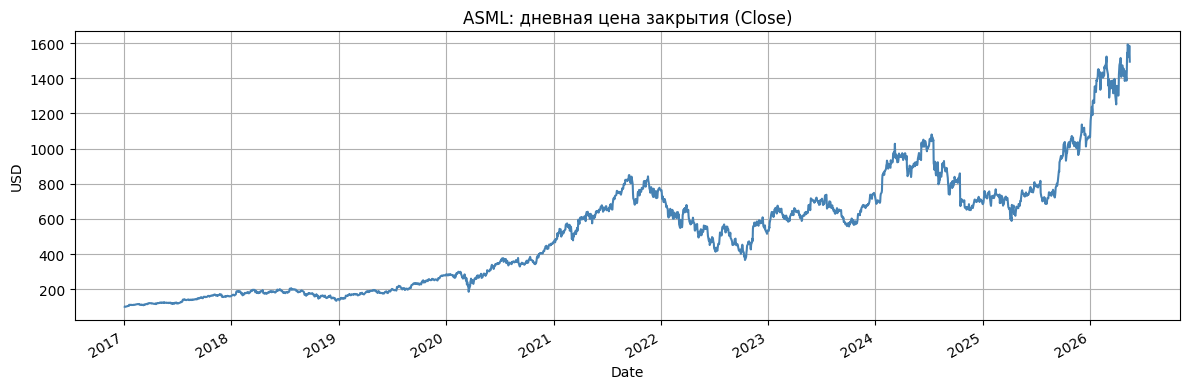

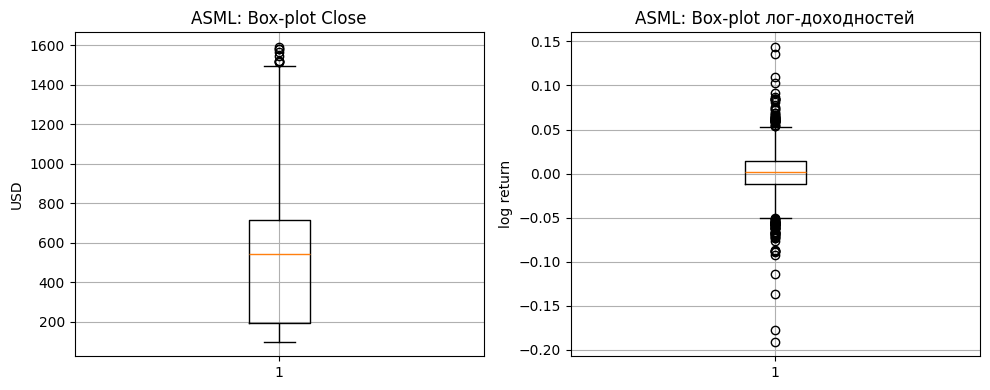

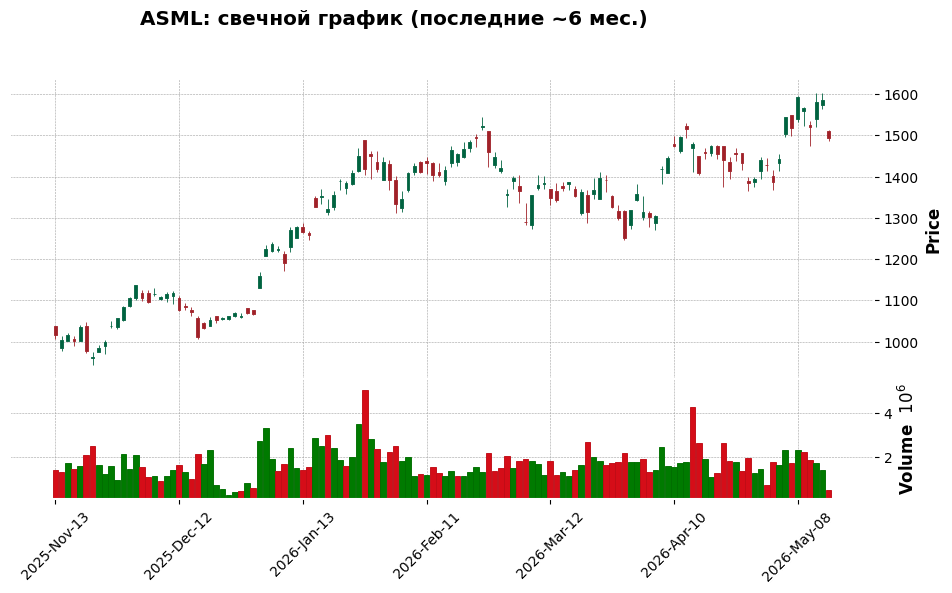

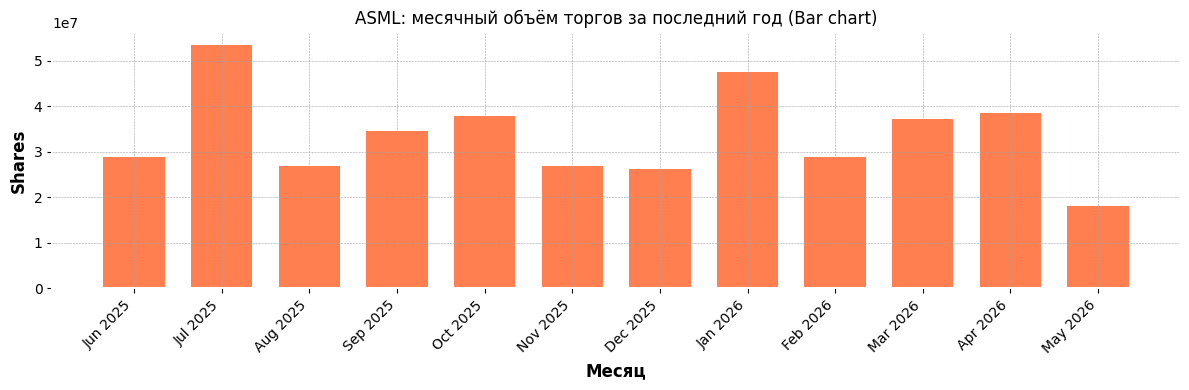


--- Стационарность ---
Слабая стационарность: постоянное среднее, постоянная дисперсия, ковариация зависит только от лага (не от календарной даты). Её проверяем ADF и ACF.
Строгая стационарность: любое совместное распределение (P_t, P_{t+1}, …) не меняется при сдвиге по времени — включая форму распределения, хвосты, кластеры волатильности. На практике это требует бесконечной выборки и знания всего закона распределения; у одной истории котировок мы видим только среднее/дисперсию/корреляции. Режим рынка меняется (кризисы, отчётность), поэтому строгую стационарность не тестируем — ограничиваемся слабой через ADF.

=== Тест на стационарность (ADF): Close ===
Test Statistic                    0.602246
p-value                           0.987671
#Lags Used                        2.000000
Number of Observations Used    2352.000000
Critical Value (1%)              -3.433133
Critical Value (5%)              -2.862770
Critical Value (10%)             -2.567425
Вывод (α=0.05): нет оснований счита

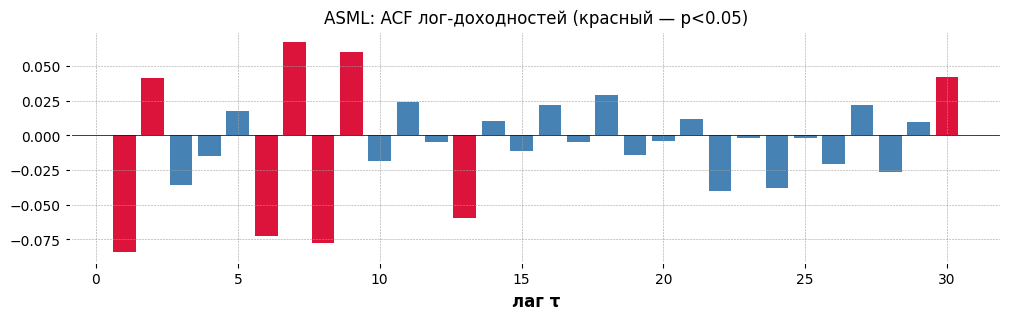

Оценим стационарность (ADF) и автокорреляцию (ACF/PACF) для:
 	ASML: лог-доходности.

=== Тест на стационарность (ADF): ASML: лог-доходности ===
Test Statistic                -1.656265e+01
p-value                        1.901125e-29
#Lags Used                     8.000000e+00
Number of Observations Used    2.345000e+03
Critical Value (1%)           -3.433142e+00
Critical Value (5%)           -2.862773e+00
Critical Value (10%)          -2.567427e+00
Вывод (α=0.05): стационарен



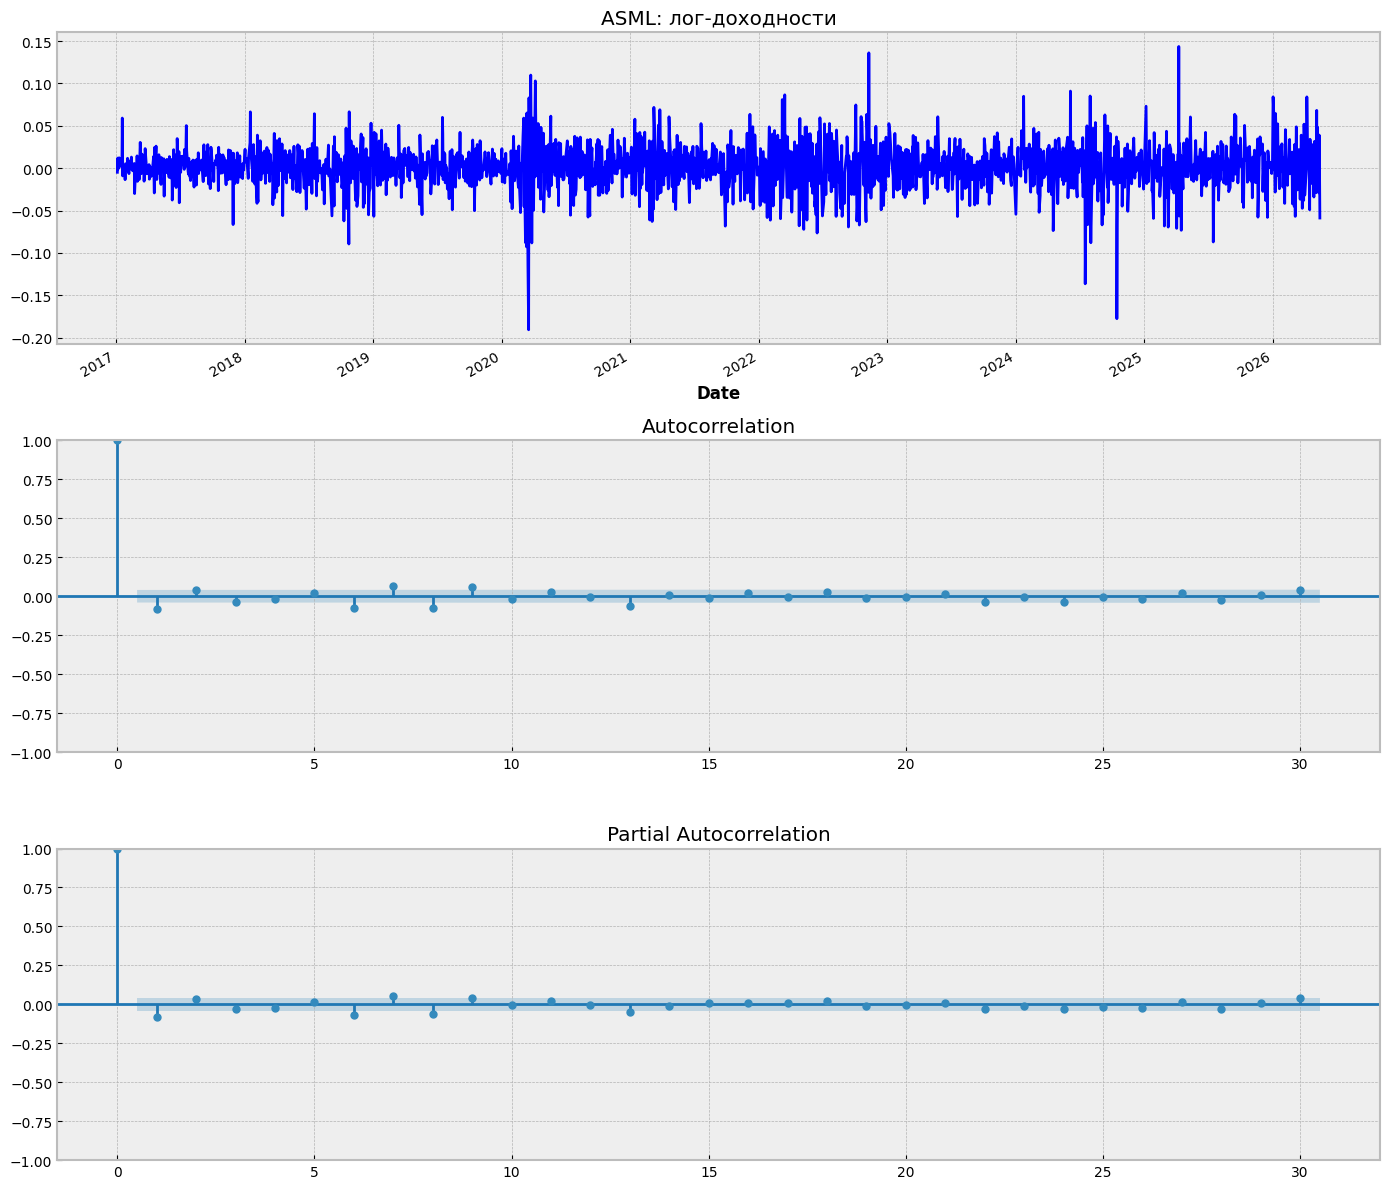


--- Приведение к стационарности ---
Close: тренд → нестационарен (единичный корень).
=== Тест на стационарность (ADF): log(Close) ===
Test Statistic                   -0.926241
p-value                           0.779208
#Lags Used                        9.000000
Number of Observations Used    2345.000000
Critical Value (1%)              -3.433142
Critical Value (5%)              -2.862773
Critical Value (10%)             -2.567427
Вывод (α=0.05): нет оснований считать стационарным

Первая разность лог-цены = лог-доходность (убираем тренд уровня).
=== Тест на стационарность (ADF): log-returns ===
Test Statistic                -1.656265e+01
p-value                        1.901125e-29
#Lags Used                     8.000000e+00
Number of Observations Used    2.345000e+03
Critical Value (1%)           -3.433142e+00
Critical Value (5%)           -2.862773e+00
Critical Value (10%)          -2.567427e+00
Вывод (α=0.05): стационарен

Комментарий (ADF, лог-доходности): при p-value < 0.05 отвер

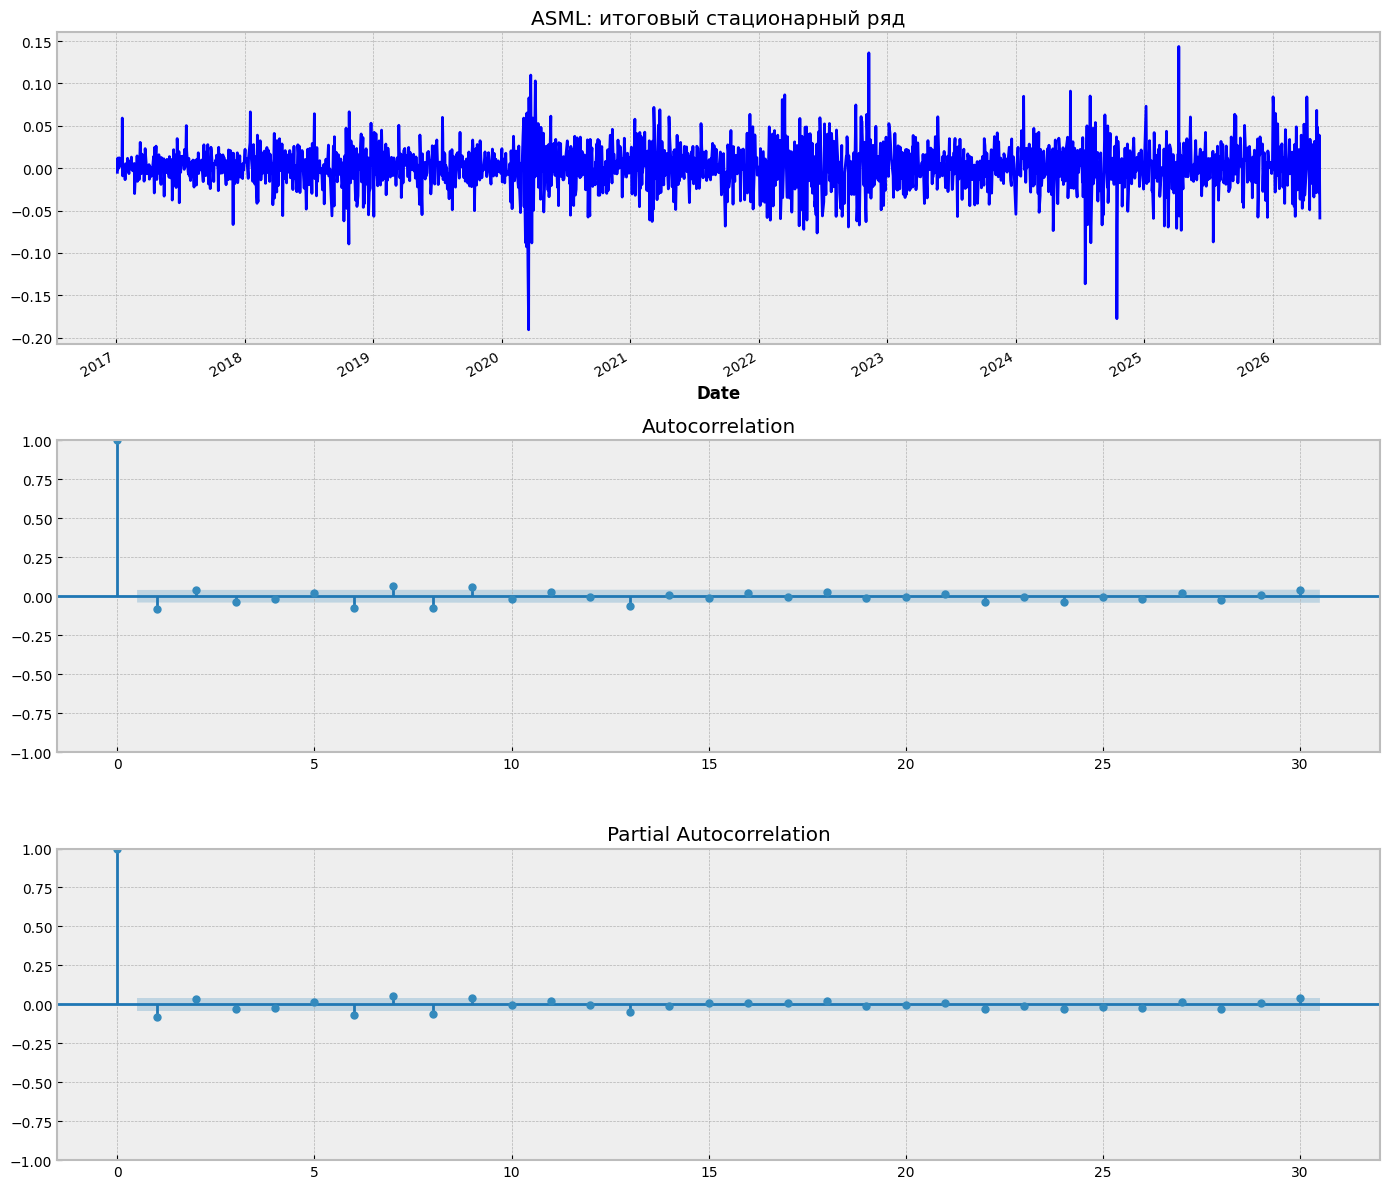

In [5]:
results_asml = analyze_ticker('ASML', data['ASML'])

### Выводы по ASML

- **Close** — на линейном графике выраженный восходящий тренд; по ADF p ≈ 0.99 (H₀ единичного корня не отвергаем) → ряд **нестационарен**.
- **Лог-доходности** — без тренда в уровне, σ ≈ 0.025; по ADF p < 0.05 → **слабая стационарность**; преобразование: `diff(log Close)`.
- **ACF** — значимы лаги 1, 2, 6–9, 13, 30 (t-критерий, α = 0.05): слабая краткосрочная автокорреляция, не долгий тренд цены.
- **Итог:** для ACF/ADF используем лог-доходности; Close — для описания динамики цены и визуализаций.

### WMT — исследование

  Walmart (WMT)

--- Описательная статистика: Close ---


,Close
count,2355.000000
mean,50.512812
std,26.764478
min,18.697338
25%,30.911893
50%,43.867188
75%,53.292768
max,133.361267



--- Описательная статистика: лог-доходности ---


,log_return
count,2354.000000
mean,0.000815
std,0.013806
min,-0.120765
25%,-0.005573
50%,0.000917
75%,0.007308
max,0.110722



Комментарий: суточная σ лог-доходностей = 0.0138; среднее ≈ 0.0008 (0.081% в день). Разброс на box-plot отражает волатильность дневных изменений цены; выбросы — дни с резкими движениями.

--- Визуализации: line, box, candlestick, bar ---


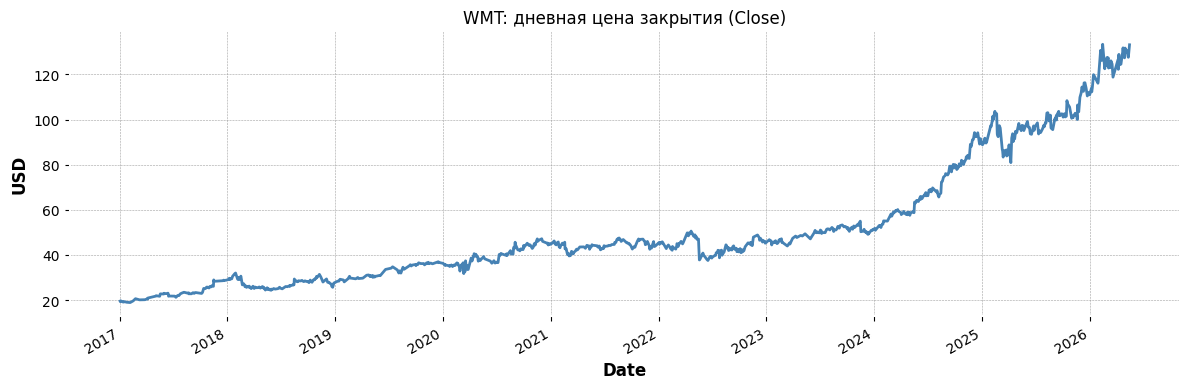

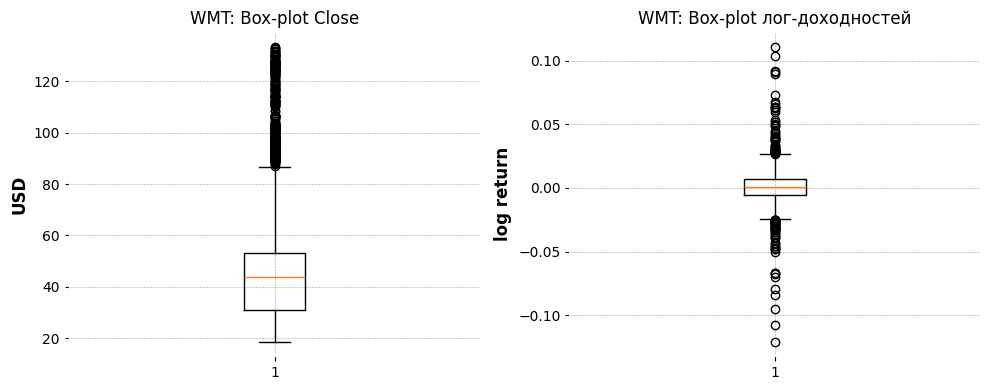

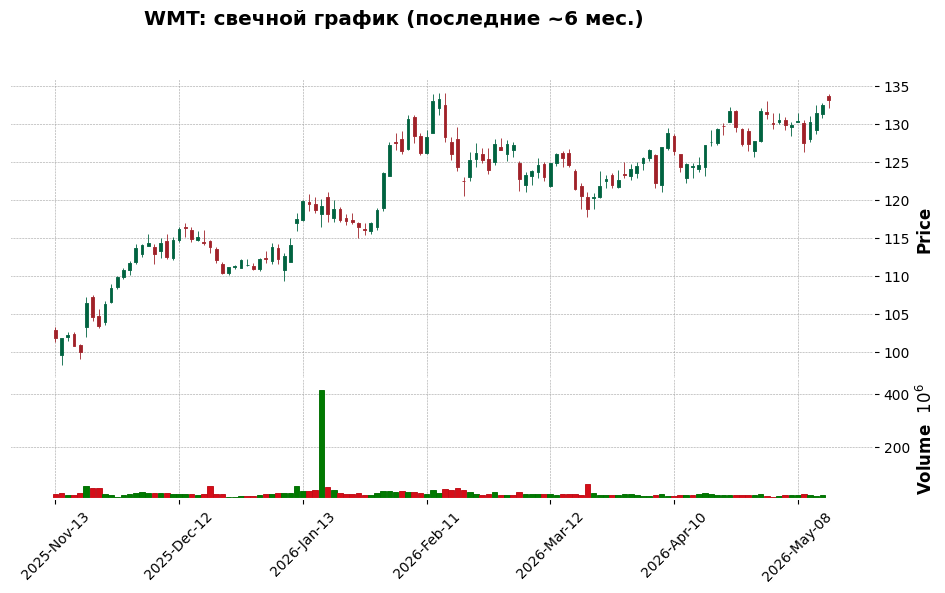

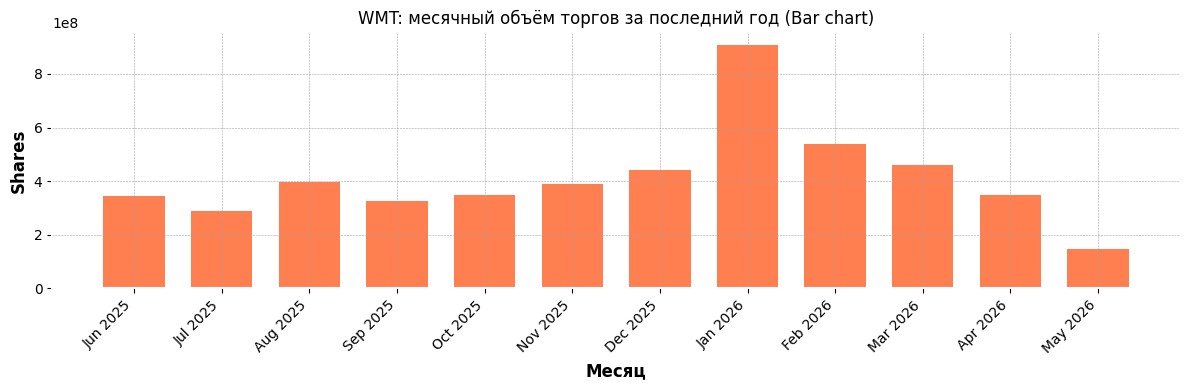


--- Стационарность ---
Слабая стационарность: постоянное среднее, постоянная дисперсия, ковариация зависит только от лага (не от календарной даты). Её проверяем ADF и ACF.
Строгая стационарность: любое совместное распределение (P_t, P_{t+1}, …) не меняется при сдвиге по времени — включая форму распределения, хвосты, кластеры волатильности. На практике это требует бесконечной выборки и знания всего закона распределения; у одной истории котировок мы видим только среднее/дисперсию/корреляции. Режим рынка меняется (кризисы, отчётность), поэтому строгую стационарность не тестируем — ограничиваемся слабой через ADF.

=== Тест на стационарность (ADF): Close ===
Test Statistic                    3.057479
p-value                           1.000000
#Lags Used                       25.000000
Number of Observations Used    2329.000000
Critical Value (1%)              -3.433161
Critical Value (5%)              -2.862782
Critical Value (10%)             -2.567431
Вывод (α=0.05): нет оснований счита

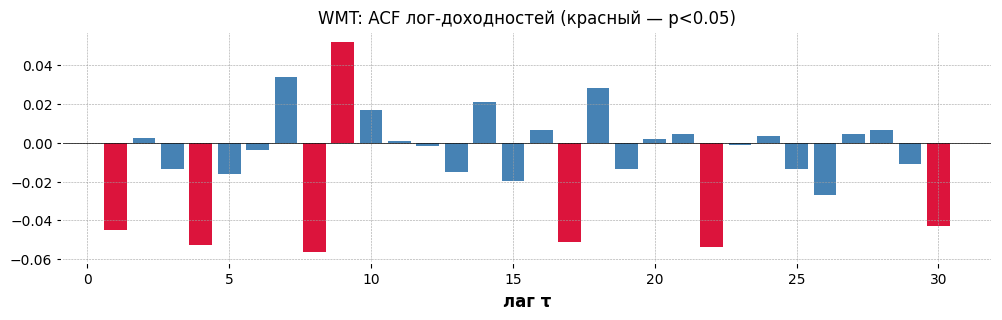

Оценим стационарность (ADF) и автокорреляцию (ACF/PACF) для:
 	WMT: лог-доходности.

=== Тест на стационарность (ADF): WMT: лог-доходности ===
Test Statistic                -1.653417e+01
p-value                        2.010919e-29
#Lags Used                     8.000000e+00
Number of Observations Used    2.345000e+03
Critical Value (1%)           -3.433142e+00
Critical Value (5%)           -2.862773e+00
Critical Value (10%)          -2.567427e+00
Вывод (α=0.05): стационарен



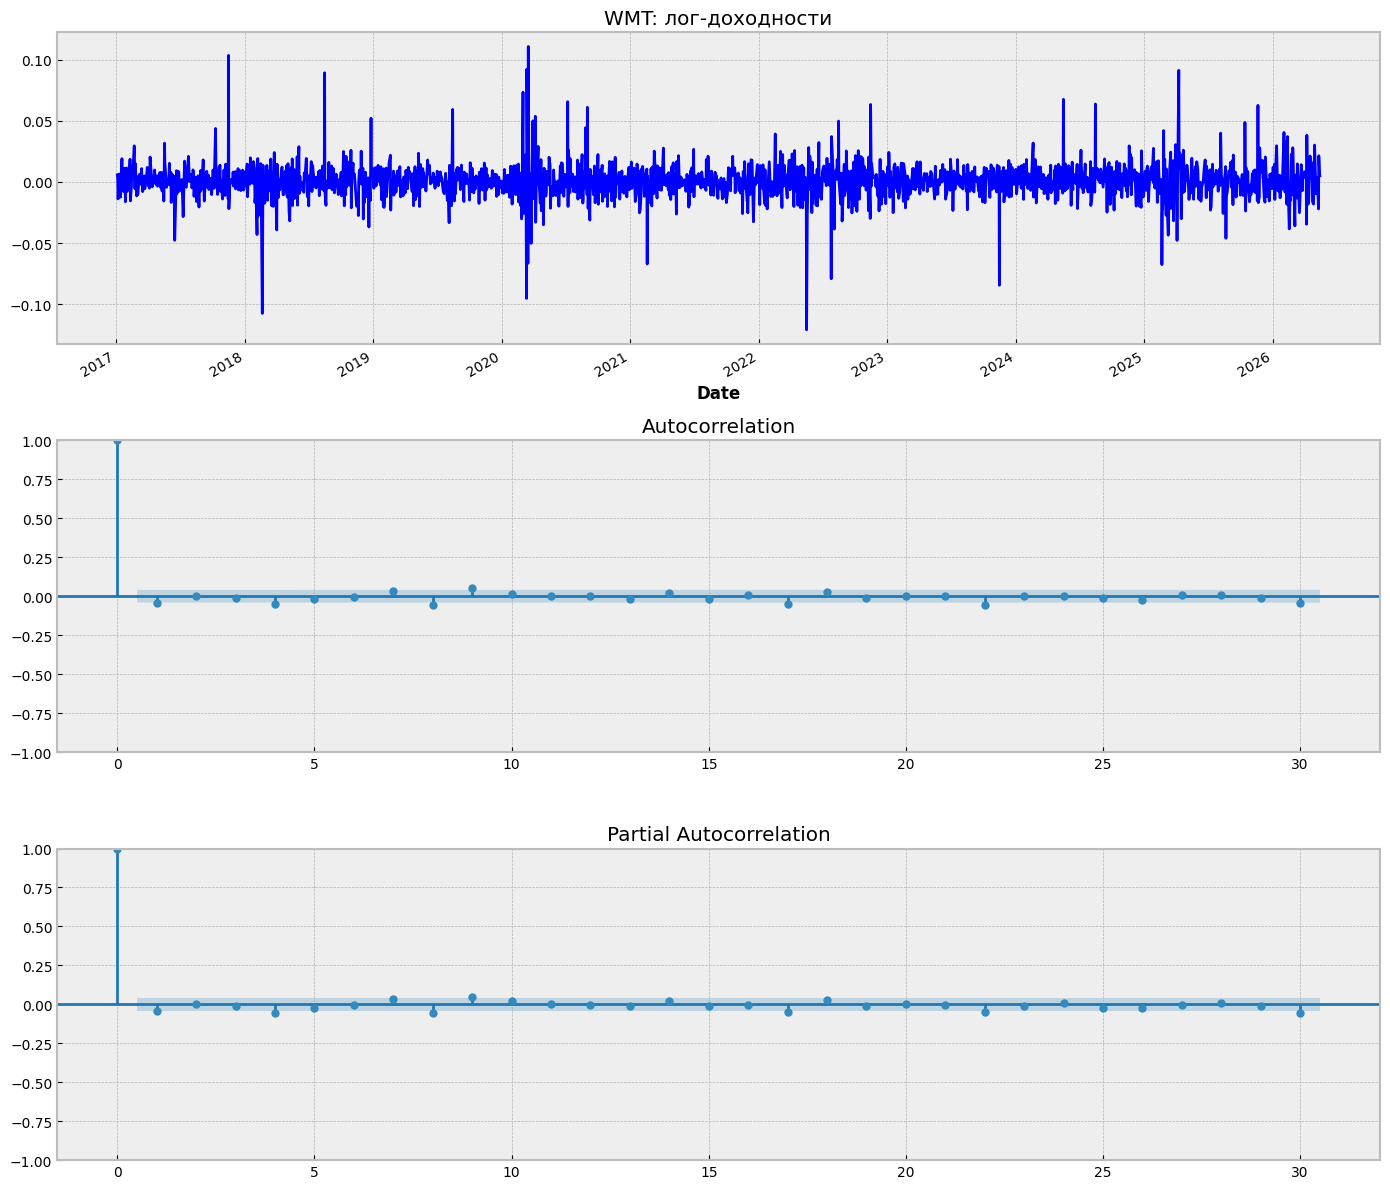


--- Приведение к стационарности ---
Close: тренд → нестационарен (единичный корень).
=== Тест на стационарность (ADF): log(Close) ===
Test Statistic                    0.204756
p-value                           0.972527
#Lags Used                        9.000000
Number of Observations Used    2345.000000
Critical Value (1%)              -3.433142
Critical Value (5%)              -2.862773
Critical Value (10%)             -2.567427
Вывод (α=0.05): нет оснований считать стационарным

Первая разность лог-цены = лог-доходность (убираем тренд уровня).
=== Тест на стационарность (ADF): log-returns ===
Test Statistic                -1.653417e+01
p-value                        2.010919e-29
#Lags Used                     8.000000e+00
Number of Observations Used    2.345000e+03
Critical Value (1%)           -3.433142e+00
Critical Value (5%)           -2.862773e+00
Critical Value (10%)          -2.567427e+00
Вывод (α=0.05): стационарен

Комментарий (ADF, лог-доходности): при p-value < 0.05 отвер

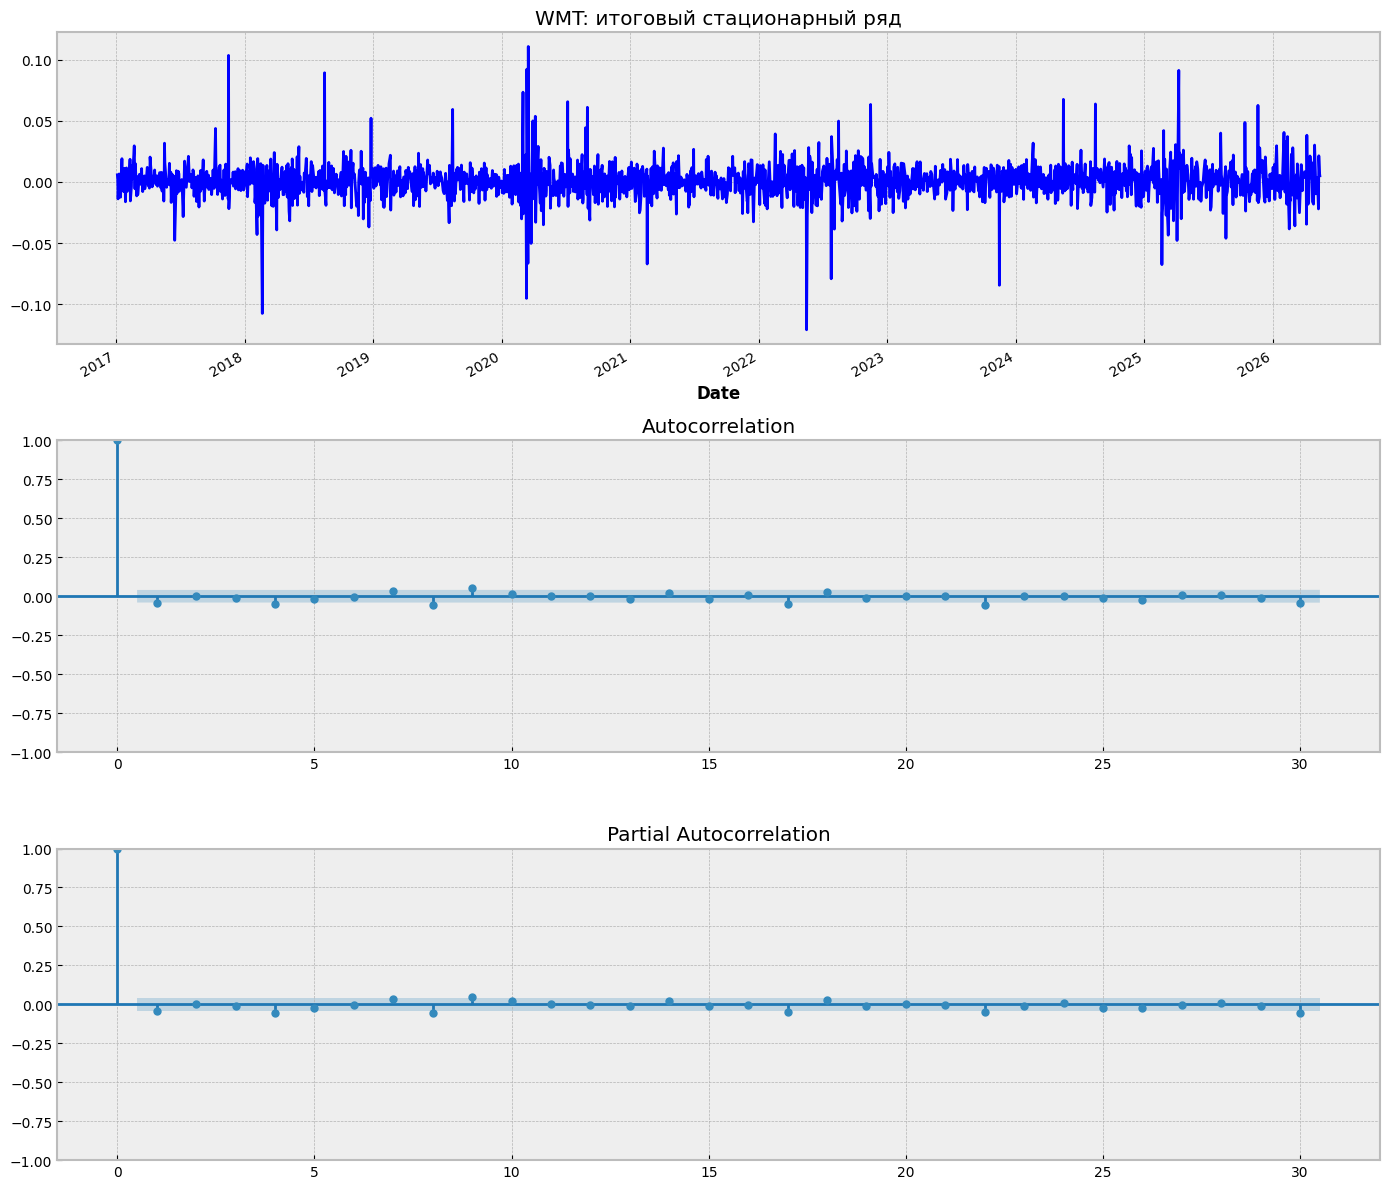

In [6]:
results_wmt = analyze_ticker('WMT', data['WMT'])

### Выводы по WMT

- **Close** — более плавный рост, чем у ASML; по ADF p = 1.0 → ряд **нестационарен** (случайное блуждание с трендом).
- **Лог-доходности** — σ ≈ 0.014 (примерно в 1.8 раза ниже ASML); box-plot уже; ADF p < 0.05 → **стационарны** после `diff(log Close)`.
- **ACF** — значимы лаги 1, 4, 8, 9, 17, 22, 30: отдельные дни слегка связаны, но уровень цены стационаризирован.
- **Итог:** стационарный ряд для анализа — лог-доходности; WMT даёт менее волатильные дневные изменения, чем ASML.

## Сравнение ASML и WMT

На графиках ниже: оба ряда лог-доходностей колеблются вокруг нуля (без тренда уровня), но **ASML** заметно «шире» по σ; индексированные цены показывают разный масштаб роста за 2017–2026. Оба актива по ADF на Close нестационарны, на доходностях — стационарны.

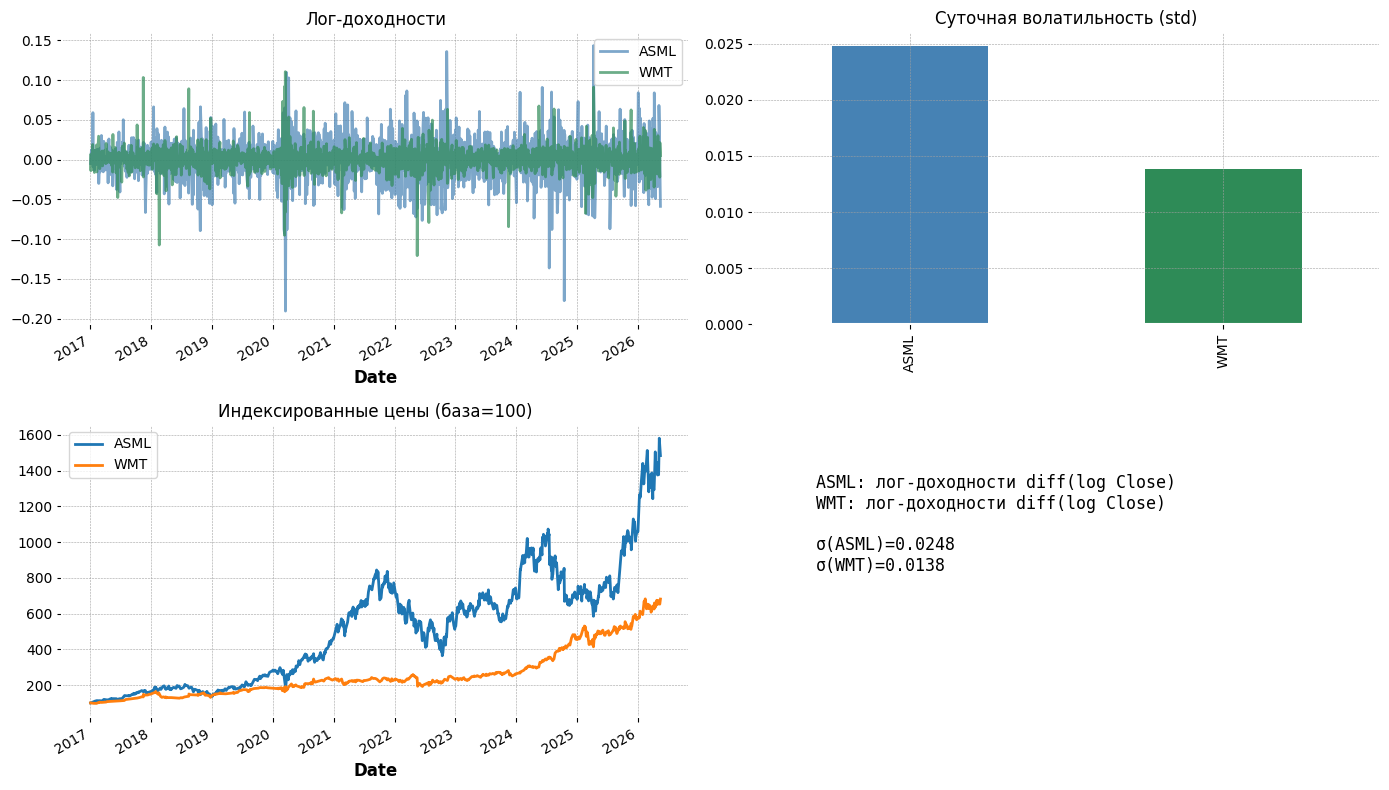

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

results_asml['log_returns'].plot(ax=axes[0, 0], color='steelblue', alpha=0.7, label='ASML')
results_wmt['log_returns'].plot(ax=axes[0, 0], color='seagreen', alpha=0.7, label='WMT')
axes[0, 0].set_title('Лог-доходности')
axes[0, 0].legend()

vol = pd.Series({
    'ASML': results_asml['log_returns'].std(),
    'WMT': results_wmt['log_returns'].std(),
})
vol.plot(kind='bar', ax=axes[0, 1], color=['steelblue', 'seagreen'])
axes[0, 1].set_title('Суточная волатильность (std)')

norm = pd.DataFrame({
    'ASML': 100 * results_asml['close'] / results_asml['close'].iloc[0],
    'WMT': 100 * results_wmt['close'] / results_wmt['close'].iloc[0],
})
norm.plot(ax=axes[1, 0])
axes[1, 0].set_title('Индексированные цены (база=100)')
axes[1, 0].legend(['ASML', 'WMT'])

axes[1, 1].axis('off')
text = (
    f"ASML: {results_asml['transform']}\n"
    f"WMT: {results_wmt['transform']}\n\n"
    f"σ(ASML)={results_asml['log_returns'].std():.4f}\n"
    f"σ(WMT)={results_wmt['log_returns'].std():.4f}"
)
axes[1, 1].text(0.1, 0.5, text, fontsize=12, family='monospace')

plt.tight_layout()
plt.show()

## Итоговые выводы

По дневным котировкам ASML и Walmart (2017–2026) **уровни цен закрытия нестационарны** по тесту Дики–Фуллера (p > 0.05), а **лог-доходности стационарны** после первой разности лог-цены (p < 0.05) — тренд снят преобразованием `r_t = Δ log(Close_t)`. Суточная волатильность ASML выше (σ ≈ 0.025 против ≈ 0.014 у WMT), что видно по описательной статистике и box-plot. На коррелограммах доходностей значима автокорреляция на отдельных коротких лагах, то есть ряд не «идеальный белый шум», но для анализа (ADF, ACF) используем лог-доходности; **Close** оставляем для графиков тренда и свечей.

| Критерий | ASML | WMT |
|----------|------|-----|
| Сектор | Полупроводники | Розница |
| σ лог-доходностей | ≈ 0.025 | ≈ 0.014 |
| Close (ADF) | Нестационарен (p ≈ 0.99) | Нестационарен (p = 1.0) |
| Лог-доходности (ADF) | Стационарны (p < 0.05) | Стационарны (p < 0.05) |